## Normalización de Datos y Validación Semántica Matemática

Los objetivos de este notebook son: cuantificar el rendimiento de los modelos SOTA evaluando la distancia matemática entre la pregunta generada y el núcleo de información original y calcular la **Similitud del Coseno** respecto al centroide de cada clúster para seleccionar algorítmicamente la "Pregunta Maestra" ganadora para cada una de las 12 categorías.

### Validación Matemática: Similitud Coseno frente al Centroide Original
Para garantizar que la selección de la "Pregunta Maestra" de cada clúster no dependa de un criterio cualitativo o de una evaluación humana susceptible a sesgos, se implementa una métrica de validación algorítmica y determinista.

**Metodología de Validación:**
1. **Proyección Vectorial:** Se utiliza el modelo de *Embeddings* (`paraphrase-multilingual-MiniLM-L12-v2`) para proyectar tanto los párrafos originales deduplicados como las preguntas generadas por los LLMs en el mismo espacio semántico multidimensional.
2. **Cálculo del Centroide:** Para cada uno de los 12 clústeres, se calcula su *Centroide* (la media aritmética espacial de todos sus vectores). Este punto geométrico exacto representa el "núcleo de la verdad clínica" del grupo.
3. **Medición de Distancia:** Se calcula la **Similitud del Coseno** entre la pregunta propuesta por cada modelo y el centroide del clúster correspondiente.
4. **Selección Algorítmica:** El modelo cuya pregunta alcance la mayor similitud cosenoidal es elegido automáticamente como el ganador. Esto asegura que la pregunta elegida sea matemáticamente la representación más fiel a la normativa original de la AEMPS.

c:\Users\04jul\Desktop\CDIA\TFG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 332.33it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings de los párrafos originales (59k fragmentos)...


Batches: 100%|██████████| 869/869 [11:45<00:00,  1.23it/s]
C:\Users\04jul\AppData\Local\Temp\ipykernel_22420\1179456608.py:101: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\04jul\AppData\Local\Temp\ipykernel_22420\1179456608.py:102: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('comparativa_modelos_barras.png', dpi=300)
c:\Users\04jul\Desktop\CDIA\TFG\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


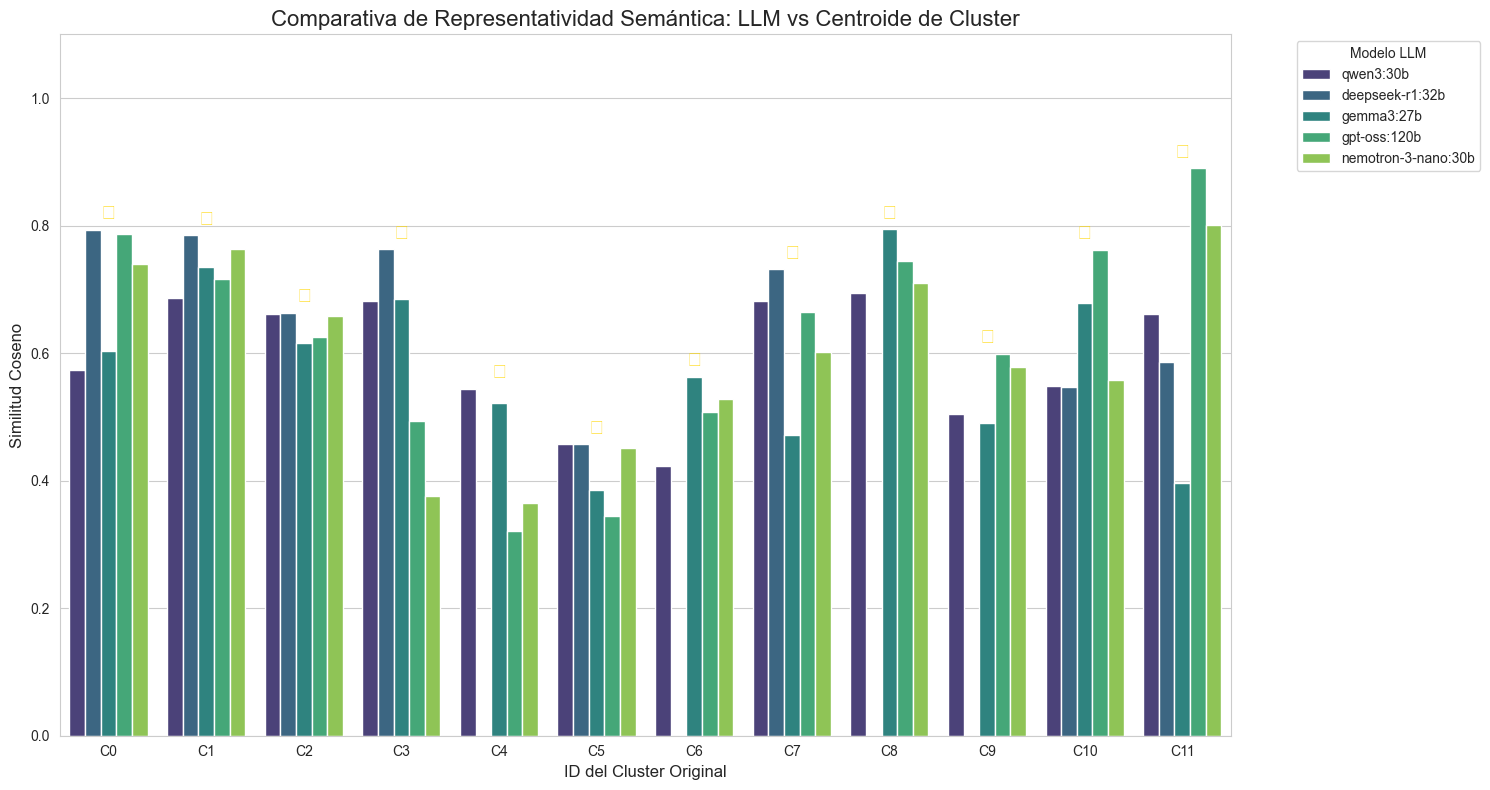


--- RESUMEN DE MEJORES MODELOS POR CLUSTER ---
    cluster_id   modelo_ganador  max_similitud
0            0  deepseek-r1:32b       0.793414
1            1  deepseek-r1:32b       0.785469
2            2  deepseek-r1:32b       0.663589
3            3  deepseek-r1:32b       0.762890
4            4        qwen3:30b       0.543992
5            5  deepseek-r1:32b       0.457269
6            6       gemma3:27b       0.563192
7            7  deepseek-r1:32b       0.732055
8            8       gemma3:27b       0.794342
9            9     gpt-oss:120b       0.599441
10          10     gpt-oss:120b       0.762544
11          11     gpt-oss:120b       0.889918


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

df_preguntas = pd.read_csv('preguntas_originales_v4_5modelos.csv')
df_parrafos = pd.read_csv('prospectos_clusters12.csv') 

# Lista de modelos a evaluar
modelos_evaluar = [
    'qwen3:30b', 
    'deepseek-r1:32b', 
    'gemma3:27b', 
    'gpt-oss:120b', 
    'nemotron-3-nano:30b'
]

print("Generando embeddings de los párrafos originales (59k fragmentos)...")
parrafos_embs = model.encode(df_parrafos['parrafo_anonimizado'].tolist(), show_progress_bar=True)
df_parrafos['embedding'] = list(parrafos_embs)

def calcular_matriz_similitud(df_q, df_p):
    res_plot = []
    ganadores = []

    for _, row in df_q.iterrows():
        c_id = row['cluster_id']
        
        # 1. Obtener centroide del cluster original
        cluster_subset = df_p[df_p['cluster'] == c_id]
        if cluster_subset.empty: continue
        
        embs_cluster = np.stack(cluster_subset['embedding'].values)
        centroide = np.mean(embs_cluster, axis=0).reshape(1, -1)
        
        mejor_sim = -1
        mejor_mod = ""
        
        # 2. Calcular similitud para cada uno de los 5 modelos
        for mod in modelos_evaluar:
            texto_pregunta = str(row[mod])
            
            if texto_pregunta in ["N/A", "ERROR_SERVIDOR", "nan", ""]:
                sim = 0
            else:
                emb_q = model.encode([texto_pregunta])
                sim = cosine_similarity(emb_q, centroide)[0][0]
            
            res_plot.append({
                'Cluster': f"C{c_id}",
                'Modelo': mod,
                'Similitud': sim
            })
            
            if sim > mejor_sim:
                mejor_sim = sim
                mejor_mod = mod
        
        ganadores.append({
            'cluster_id': c_id,
            'modelo_ganador': mejor_mod,
            'max_similitud': mejor_sim,
            'pregunta': row[mejor_mod]
        })

    return pd.DataFrame(res_plot), pd.DataFrame(ganadores)


df_plot, df_ganadores = calcular_matriz_similitud(df_preguntas, df_parrafos)

# Visualización
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")


ax = sns.barplot(data=df_plot, x='Cluster', y='Similitud', hue='Modelo', palette='viridis')


for i, winner_row in df_ganadores.iterrows():
    cluster_name = f"C{winner_row['cluster_id']}"
    max_val = winner_row['max_similitud']
    plt.text(i, max_val + 0.01, '★', ha='center', va='bottom', color='gold', fontsize=15, fontweight='bold')

plt.title('Comparativa de Representatividad Semántica: LLM vs Centroide de Cluster', fontsize=16)
plt.ylabel('Similitud Coseno', fontsize=12)
plt.xlabel('ID del Cluster Original', fontsize=12)
plt.ylim(0, 1.1) # Similitud va de 0 a 1
plt.legend(title='Modelo LLM', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('comparativa_modelos_barras.png', dpi=300)
plt.show()

print("\n--- RESUMEN DE MEJORES MODELOS POR CLUSTER ---")
print(df_ganadores[['cluster_id', 'modelo_ganador', 'max_similitud']])
df_ganadores.to_csv('mejores_preguntas_validadas.csv', index=False)

### Resultados
El cálculo de la Similitud del Coseno frente a los centroides originales revela un hallazgo: **la especialización temática de los Modelos de Lenguaje**. Los datos de la tabla de ganadores demuestran que ningún modelo posee una superioridad absoluta, justificando la estrategia de usar un "Comité de Expertos" (Ensemble).

Desglose analítico de los ganadores:
1. **Dominio Clínico-Instructivo (DeepSeek-R1 32B):** Es el ganador mayoritario, imponiéndose en 6 de los 12 clústeres (0, 1, 2, 3, 5 y 7). Su arquitectura centrada en el razonamiento le permite abstraer con máxima precisión (cosenos de hasta 0.79) temas vitales como la posología, el embarazo y el manejo de olvidos de dosis.
2. **Dominio Burocrático-Administrativo (GPT-OSS 120B):** La inmensa capacidad paramétrica de este modelo (120 billones) barre por completo en la sección final del prospecto (Clusters 9, 10 y 11), alcanzando el pico máximo de similitud de todo el estudio (**0.889** en el Cluster 11, referente a fechas de revisión y conservación).
3. **Victorias Tácticas en Seguridad (Gemma-3 y Qwen3):** En clústeres donde la información es densa y centrada en advertencias o efectos secundarios complejos, modelos como Gemma-3 (Clusters 6 y 8) y Qwen3 (Cluster 4) logran extraer la intención del paciente mejor que los modelos de razonamiento puro.

### Validación: Similitud Promedio Intra-Clúster
Para garantizar que la selección de la "Pregunta Maestra" esté libre de sesgos heurísticos, se diseña una métrica de validación algorítmica y determinista. En lugar de utilizar una aproximación por centroides, se implementa un cálculo de **Similitud Coseno Promedio**.

**Metodología de Validación Espacial:**
1. **Vectorización Masiva:** Se utiliza el modelo `paraphrase-multilingual-MiniLM-L12-v2` para proyectar los 59.000 párrafos deduplicados y las preguntas generadas por los LLMs en un espacio semántico denso.
2. **Cálculo Exhaustivo (Uno a Todos):** Para cada clúster, se calcula la Distancia del Coseno entre la pregunta propuesta por un modelo y **cada uno de los párrafos individuales** que componen dicho clúster. 
3. **Promedio:** Se extrae la media aritmética de todas estas similitudes. Este enfoque penaliza a las preguntas que se sobreajustan a un párrafo anómalo (outlier) y premia a aquellas que capturan la intención general de la inmensa mayoría de los textos.
4. **Coronación Algorítmica:** El modelo con el promedio de similitud más alto obtiene la validación matemática (indicado con una estrella ★ en la visualización).

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 473.66it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generando embeddings de los párrafos originales (59k fragmentos)...


Batches: 100%|██████████| 869/869 [11:20<00:00,  1.28it/s]


Calculando similitudes promedio por cluster...


C:\Users\04jul\AppData\Local\Temp\ipykernel_22420\1603599164.py:106: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\04jul\AppData\Local\Temp\ipykernel_22420\1603599164.py:107: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('comparativa_modelos_promedio.png', dpi=300)
c:\Users\04jul\Desktop\CDIA\TFG\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


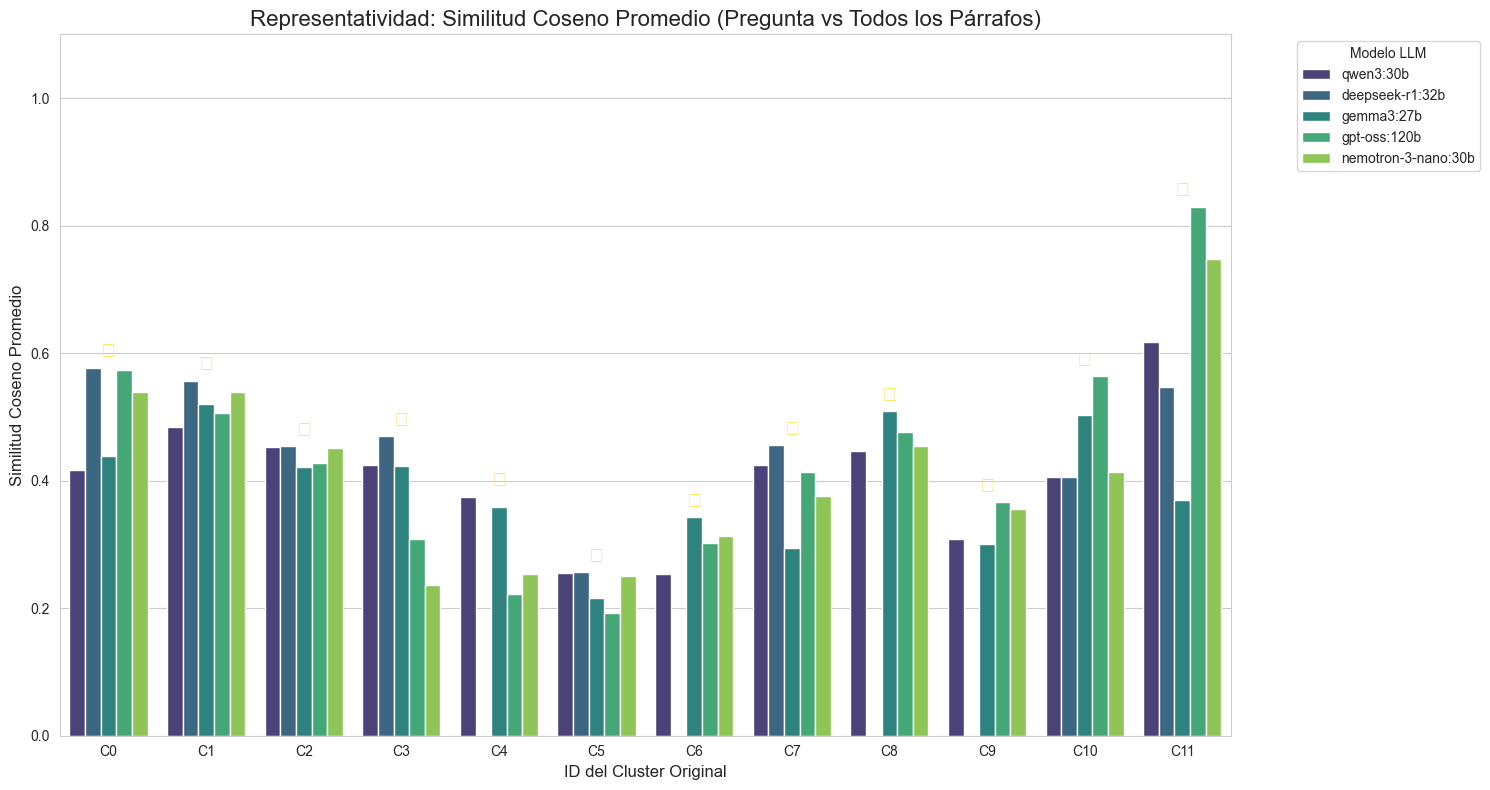


--- RESUMEN DE MEJORES MODELOS (BASADO EN SIMILITUD PROMEDIO) ---
    cluster_id   modelo_ganador  max_similitud
0            0  deepseek-r1:32b       0.577239
1            1  deepseek-r1:32b       0.556983
2            2  deepseek-r1:32b       0.453908
3            3  deepseek-r1:32b       0.469959
4            4        qwen3:30b       0.374731
5            5  deepseek-r1:32b       0.256594
6            6       gemma3:27b       0.343097
7            7  deepseek-r1:32b       0.455721
8            8       gemma3:27b       0.509155
9            9     gpt-oss:120b       0.366583
10          10     gpt-oss:120b       0.564086
11          11     gpt-oss:120b       0.829626


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

df_preguntas = pd.read_csv('preguntas_originales_v4_5modelos.csv')
df_parrafos = pd.read_csv('prospectos_clusters12.csv') 

modelos_evaluar = [
    'qwen3:30b', 
    'deepseek-r1:32b', 
    'gemma3:27b', 
    'gpt-oss:120b', 
    'nemotron-3-nano:30b'
]

print("Generando embeddings de los párrafos originales (59k fragmentos)...")
parrafos_embs = model.encode(df_parrafos['parrafo_anonimizado'].tolist(), show_progress_bar=True)
df_parrafos['embedding'] = list(parrafos_embs)

def calcular_matriz_similitud(df_q, df_p):
    res_plot = []
    ganadores = []

    for _, row in df_q.iterrows():
        c_id = row['cluster_id']
        
        # 1. Obtener todos los párrafos del cluster original
        cluster_subset = df_p[df_p['cluster'] == c_id]
        if cluster_subset.empty: continue
        
        # Convertir lista de embeddings del cluster a una matriz numpy
        embs_cluster = np.stack(cluster_subset['embedding'].values)
        
        mejor_sim_promedio = -1
        mejor_mod = ""
        
        # 2. Calcular similitud promedio para cada uno de los 5 modelos
        for mod in modelos_evaluar:
            texto_pregunta = str(row[mod])
            
            # Manejo de errores o celdas vacías
            if texto_pregunta in ["N/A", "ERROR_SERVIDOR", "nan", ""]:
                sim_promedio = 0
            else:
                emb_q = model.encode([texto_pregunta])
                # Calculamos la similitud de la pregunta contra CADA párrafo del cluster
                similitudes_todas = cosine_similarity(emb_q, embs_cluster)[0]
                # Hacemos el promedio de todas esas similitudes
                sim_promedio = np.mean(similitudes_todas)
            
            res_plot.append({
                'Cluster': f"C{c_id}",
                'Modelo': mod,
                'Similitud': sim_promedio
            })
            
            if sim_promedio > mejor_sim_promedio:
                mejor_sim_promedio = sim_promedio
                mejor_mod = mod
        
        ganadores.append({
            'cluster_id': c_id,
            'modelo_ganador': mejor_mod,
            'max_similitud': mejor_sim_promedio,
            'pregunta': row[mejor_mod]
        })

    return pd.DataFrame(res_plot), pd.DataFrame(ganadores)


print("Calculando similitudes promedio por cluster...")
df_plot, df_ganadores = calcular_matriz_similitud(df_preguntas, df_parrafos)

# Visualización
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Gráfico de barras agrupadas
ax = sns.barplot(data=df_plot, x='Cluster', y='Similitud', hue='Modelo', palette='viridis')

for i, winner_row in df_ganadores.iterrows():
    max_val = winner_row['max_similitud']
    plt.text(i, max_val + 0.01, '★', ha='center', va='bottom', color='gold', fontsize=15, fontweight='bold')

plt.title('Representatividad: Similitud Coseno Promedio (Pregunta vs Todos los Párrafos)', fontsize=16)
plt.ylabel('Similitud Coseno Promedio', fontsize=12)
plt.xlabel('ID del Cluster Original', fontsize=12)
plt.ylim(0, 1.1) 
plt.legend(title='Modelo LLM', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('comparativa_modelos_promedio.png', dpi=300)
plt.show()

print("\n--- RESUMEN DE MEJORES MODELOS (BASADO EN SIMILITUD PROMEDIO) ---")
print(df_ganadores[['cluster_id', 'modelo_ganador', 'max_similitud']])
df_ganadores.to_csv('mejores_preguntas_validadas_promedio.csv', index=False)

### Resultados
La ejecución de la métrica de Similitud Promedio confirma las hipótesis planteadas en fases anteriores. 

Al analizar la tabla de ganadores, destacan dos fenómenos clave:

1. **Estabilidad de la Especialización:** A pesar del cambio de métrica, la jerarquía de especialización de los modelos se mantiene intacta. **DeepSeek-R1** domina el bloque clínico-posológico (6 clústeres), **Gemma/Qwen** ganan en los nodos complejos de seguridad (Clusters 4, 6 y 8), y  **GPT-OSS (120B)** sigue consiguiendo mayor similitud en la información administrativa (Clusters 9, 10 y 11). Esto demuestra que las victorias no eran anomalías geométricas del centroide, sino verdaderas fortalezas semánticas de cada arquitectura neuronal.
2. **Caída Lógica de las Magnitudes:** Se observa que las similitudes máximas son numéricamente inferiores al método de centroides (ej. Cluster 0 pasa de ~0.79 a 0.57). Esto es un comportamiento matemáticamente esperado y deseable. Al medir contra cada párrafo individual en lugar de contra un vector suavizado, la media se ve arrastrada por la varianza natural del lenguaje y los *outliers*. Lograr similitudes medias cercanas a 0.50 contra miles de textos distintos certifica que la pregunta generada es un "paraguas semántico" excepcionalmente ancho y representativo.

### Experimento de Análisis Lingüístico: Segmentación Núcleo vs. Contexto
Durante la auditoría cualitativa de las preguntas generadas, se observó que algunos modelos tendían a incluir múltiples cláusulas condicionales en su respuesta (ej. *"¿Cuáles son los riesgos si tengo asma, problemas de riñón o diabetes?"*). 

Para investigar si estas preguntas podían simplificarse aún más, se diseña un experimento de **Segmentación Sintáctica Automatizada**.

**Hipótesis y Metodología:**
Se plantea que aislar la "Intención Central" (Núcleo) de las "Circunstancias" (Contexto) podría generar un índice visualmente más limpio. Para ello, se reutiliza el comité de 5 LLMs, asignándoles el rol de "Analizador Lingüístico". 
Se diseña un *Prompt* con restricciones de extracción literal (Substring Extraction) para obligar al modelo a partir su propia pregunta en dos variables JSON exactas, sin reformular ni resumir el texto original.

In [ ]:
import pandas as pd
import json
import requests


URL_OLLAMA = "https://wiig.dia.fi.upm.es/ollama/v1/chat/completions"
MODELOS = [
    'qwen3:30b', 
    'deepseek-r1:32b', 
    'gemma3:27b', 
    'gpt-oss:120b', 
    'nemotron-3-nano:30b'
]

# Preguntas generadas por LLMs
df_preguntas = pd.read_csv('preguntas_originales_v4_5modelos.csv')

def extraer_nucleo_llm(modelo, pregunta):
    """Extrae núcleo y contexto usando segmentación literal en formato JSON."""
    if pd.isna(pregunta) or not pregunta or "ERROR" in str(pregunta):
        return {"nucleo": "N/A", "contexto": "N/A"}

    prompt = f"""
    Eres un analizador lingüístico. Tu tarea es segmentar la siguiente pregunta en dos partes EXACTAS:
    1) "nucleo": La intención central o raíz de la pregunta.
    2) "contexto": Cláusulas circunstanciales, detalles, síntomas o condiciones.

    Instrucciones:
    - NO reformules el texto. NO resumas. NO interpretes.
    - Mantén EXACTAMENTE las palabras originales de la pregunta.
    - Si no hay cláusulas circunstanciales, pon "Ninguna" en contexto.
    
    Pregunta: "{pregunta}"

    Responde exclusivamente en este formato JSON:
    {{
      "nucleo": "¿<segmento_original_del_nucleo>?",
      "contexto": "<segmento_original_del_contexto>"
    }}
    """
    
    payload = {
        "model": modelo,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.0,
        "response_format": { "type": "json_object" } 
    }
    
    try:
        response = requests.post(URL_OLLAMA, json=payload, timeout=300)
        if response.status_code != 200:
            return {"nucleo": "N/A", "contexto": f"Error HTTP {response.status_code}"}
            
        contenido = response.json()['choices'][0]['message']['content']
        
        # Limpieza de etiquetas de pensamiento
        if "</think>" in contenido:
            contenido = contenido.split("</think>")[-1].strip()
            
        # Extraer JSON
        import re
        match = re.search(r'\{.*\}', contenido, re.DOTALL)
        if match:
            return json.loads(match.group())
        else:
            return {"nucleo": "N/A", "contexto": "Error Parseo JSON"}
            
    except Exception as e:
        return {"nucleo": "N/A", "contexto": f"Error: {str(e)}"}

# Para cada pregunta llamamos a los LLMs para la segmentación
print("Iniciando segmentación de preguntas (Núcleo vs Contexto)...")
resultados_segmentados = []

for _, row in df_preguntas.iterrows():
    c_id = row['cluster_id']
    print(f"\nProcesando Cluster {c_id}...")
    
    for mod in MODELOS:
        pregunta_original = str(row[mod])
        print(f"   > Segmentando con {mod}...")
        
        res = extraer_nucleo_llm(mod, pregunta_original)
        
        resultados_segmentados.append({
            'cluster_id': c_id,
            'modelo': mod,
            'pregunta_original': pregunta_original,
            'pregunta_nucleo': res.get('nucleo', 'N/A'),
            'contexto': res.get('contexto', 'N/A')
        })


df_segmentadas = pd.DataFrame(resultados_segmentados)
df_segmentadas.to_csv("preguntas_segmentadas_todos_modelos.csv", index=False, encoding='utf-8-sig')
print("\n¡Archivo 'preguntas_segmentadas_todos_modelos.csv' generado con éxito!")


Iniciando segmentación de preguntas (Núcleo vs Contexto)...

Procesando Cluster 0...
   > Segmentando con qwen3:30b...
   > Segmentando con deepseek-r1:32b...
   > Segmentando con gemma3:27b...
   > Segmentando con gpt-oss:120b...
   > Segmentando con nemotron-3-nano:30b...

Procesando Cluster 1...
   > Segmentando con qwen3:30b...
   > Segmentando con deepseek-r1:32b...
   > Segmentando con gemma3:27b...
   > Segmentando con gpt-oss:120b...
   > Segmentando con nemotron-3-nano:30b...

Procesando Cluster 2...
   > Segmentando con qwen3:30b...
   > Segmentando con deepseek-r1:32b...
   > Segmentando con gemma3:27b...
   > Segmentando con gpt-oss:120b...
   > Segmentando con nemotron-3-nano:30b...

Procesando Cluster 3...
   > Segmentando con qwen3:30b...
   > Segmentando con deepseek-r1:32b...
   > Segmentando con gemma3:27b...
   > Segmentando con gpt-oss:120b...
   > Segmentando con nemotron-3-nano:30b...

Procesando Cluster 4...
   > Segmentando con qwen3:30b...
   > Segmentando con 

### Estudio de Ablación: Impacto del Contexto en la Representatividad Semántica
Tras segmentar las preguntas en "Núcleo" y "Contexto", se diseña un experimento de ablación matemática. El objetivo es comprobar si las cláusulas circunstanciales introducidas por los LLMs (el "contexto") acercan la pregunta a la verdad clínica del prospecto, o si, por el contrario, actúan como ruido semántico.

**Actualización del Motor Vectorial (SOTA en Español):**
Para garantizar la máxima precisión en esta medición de similitud fina, se actualiza el motor de *embeddings*. Se sustituye el modelo ligero `MiniLM` por `multilingual-e5-large-ft-sts-spanish-matryoshka`. Este modelo avanzado ha sido específicamente entrenado (*Fine-Tuned*) para tareas de **Similitud Textual Semántica (STS) en español**, proporcionando una topología vectorial mucho más sensible a los matices del idioma.

**Metodología:**
Se calcula la *Similitud Coseno Promedio* intra-clúster para dos variantes de la misma pregunta:
1. La pregunta original completa.
2. Únicamente la intención central (Ablación del núcleo).

Loading weights: 100%|██████████| 391/391 [00:01<00:00, 379.42it/s, Materializing param=pooler.dense.weight]                               


Generando embeddings de los párrafos originales...


Batches: 100%|██████████| 869/869 [2:44:40<00:00, 11.37s/it]  


Calculando y comparando similitudes...


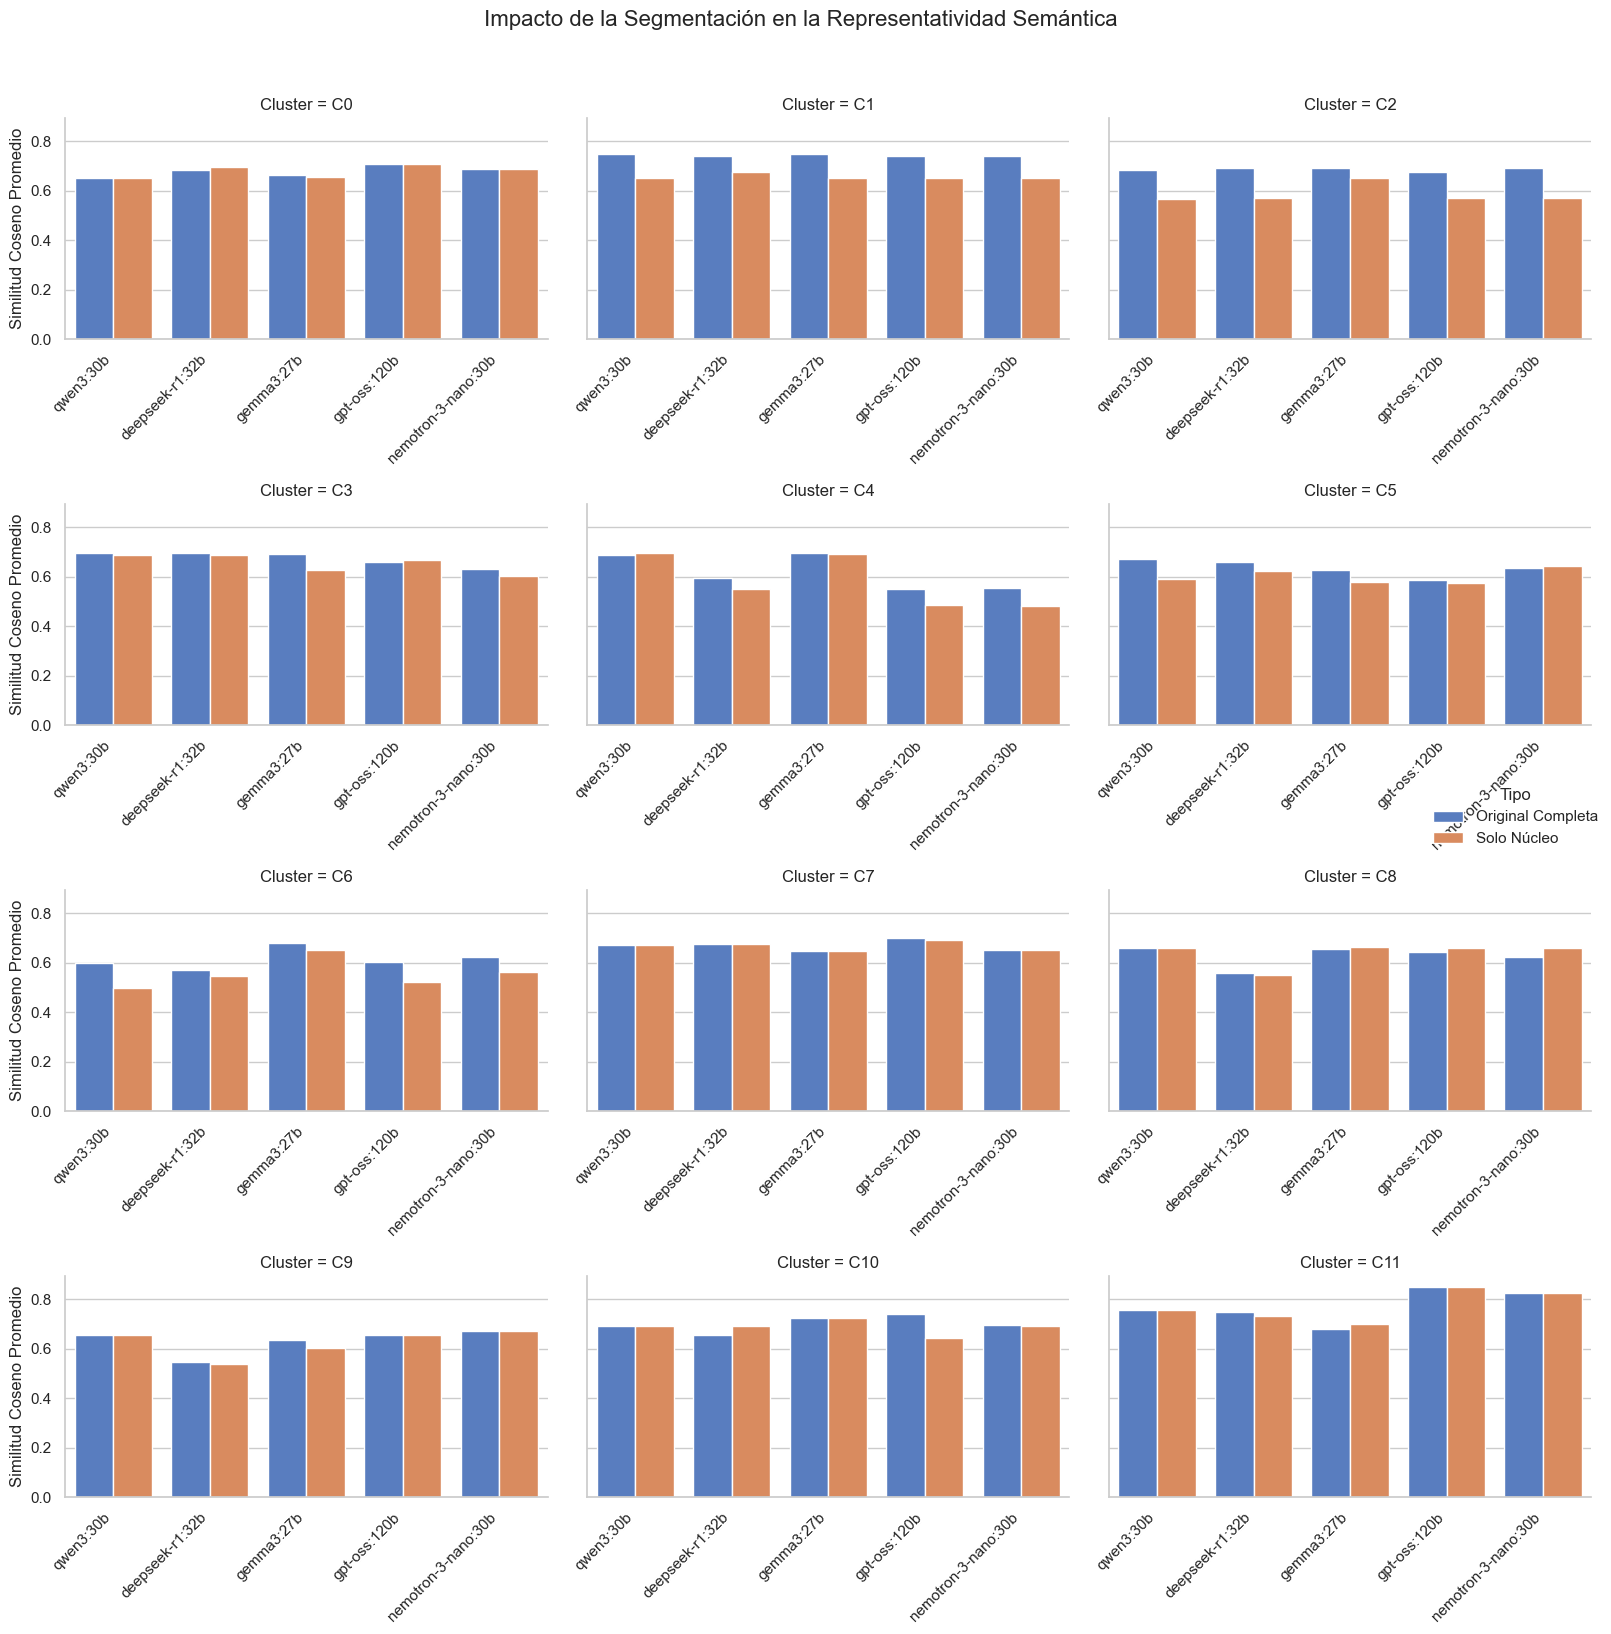


--- RESUMEN DE IMPACTO DE ABLACIÓN (NÚCLEO) ---
Mejora promedio global al usar solo el núcleo: -0.0290


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


model = SentenceTransformer('mrm8488/multilingual-e5-large-ft-sts-spanish-matryoshka-768-64-5e')

df_segmentadas = pd.read_csv('preguntas_segmentadas_todos_modelos.csv')
df_parrafos = pd.read_csv('prospectos_clusters12.csv')

print("Generando embeddings de los párrafos originales...")
parrafos_embs = model.encode(df_parrafos['parrafo_anonimizado'].tolist(), show_progress_bar=True)
df_parrafos['embedding'] = list(parrafos_embs)

# Calcular similitudes
resultados_similitud = []

print("Calculando y comparando similitudes...")
for _, row in df_segmentadas.iterrows():
    c_id = row['cluster_id']
    modelo = row['modelo']
    p_original = str(row['pregunta_original'])
    p_nucleo = str(row['pregunta_nucleo'])
    
    cluster_subset = df_parrafos[df_parrafos['cluster'] == c_id]
    if cluster_subset.empty or p_original == "nan" or p_nucleo == "N/A": 
        continue
        
    embs_cluster = np.stack(cluster_subset['embedding'].values)
    
    # Similitud Pregunta Original
    emb_orig = model.encode([p_original])
    sim_orig = np.mean(cosine_similarity(emb_orig, embs_cluster)[0])
    
    # Similitud Solo Núcleo
    emb_nuc = model.encode([p_nucleo])
    sim_nuc = np.mean(cosine_similarity(emb_nuc, embs_cluster)[0])
    
    resultados_similitud.append({
        'Cluster': f"C{c_id}",
        'Modelo': modelo,
        'Tipo': 'Original Completa',
        'Similitud': sim_orig
    })
    resultados_similitud.append({
        'Cluster': f"C{c_id}",
        'Modelo': modelo,
        'Tipo': 'Solo Núcleo',
        'Similitud': sim_nuc
    })

df_plot = pd.DataFrame(resultados_similitud)

# Visualización
# Creamos un gráfico de barras comparativo para ver Original vs Núcleo por cada modelo y cluster
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_plot, kind="bar",
    x="Modelo", y="Similitud", hue="Tipo", col="Cluster",
    col_wrap=3, height=4, aspect=1.2, palette="muted", sharex=False
)

g.fig.suptitle('Impacto de la Segmentación en la Representatividad Semántica', y=1.02, fontsize=16)
g.set_axis_labels("", "Similitud Coseno Promedio")
g.set_xticklabels(rotation=45, ha="right")

for ax in g.axes.flatten():
    ax.tick_params(labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig('comparativa_original_vs_nucleo.png', dpi=300)
plt.show()

# Calcular métrica global: ¿Mejora o empeora quitar el contexto?
df_pivot = df_plot.pivot_table(index=['Cluster', 'Modelo'], columns='Tipo', values='Similitud').reset_index()
df_pivot['Mejora_con_Nucleo'] = df_pivot['Solo Núcleo'] - df_pivot['Original Completa']

print("\n--- RESUMEN DE IMPACTO DE ABLACIÓN (NÚCLEO) ---")
print(f"Mejora promedio global al usar solo el núcleo: {df_pivot['Mejora_con_Nucleo'].mean():.4f}")
df_pivot.to_csv("impacto_nucleo_vs_original.csv", index=False)

### Resultados del Estudio de Ablación
La ejecución del *script* y el análisis de la métrica global revelan que **extirpar el contexto empeora la representatividad semántica de la pregunta**. 

Como demuestra el cálculo final de la variable `Mejora_con_Nucleo` (**-0.0290 puntos de media global**), el núcleo aislado está más alejado en el espacio vectorial que la pregunta completa. 

Este descenso en la métrica de Similitud Coseno demuestra empíricamente que las cláusulas circunstanciales generadas por los LLMs no son "ruido conversacional" ni "fugas de instrucción" (Instruction Bleed), sino **carga semántica útil**. El modelo de *embeddings* detecta que los síntomas, advertencias y situaciones específicas forman parte intrínseca de la "verdad clínica" del clúster original. Al amputar este contexto, se pierde riqueza representacional.

Se demuestra matemáticamente que la **Pregunta Completa Original (Pre-Segmentación)** es la unidad de información óptima. No solo proporciona al paciente el contexto necesario para reducir su carga cognitiva, sino que, a nivel algorítmico, captura con mayor fidelidad la densidad técnica de la literatura original de la AEMPS.
